In [ ]:
def get_bond(option):
    import pymol
    import numpy as np
    import pandas as pd
    from pymol import cmd
    pymol.pymol_argv = ['pymol', '-c']  # '-c' 表示无头模式

    from tqdm import tqdm
    from tention import get_agel

    cmd.reinitialize()

    cmd.load(protein_file, "protein")
    cmd.load(ligand_file, "ligand_file")
    
    #创建加H副本
    cmd.create("H_Protein", "Protein")
    cmd.create("H_hpepdock_all", "hpepdock_all")
    # 为蛋白质添加氢原子（只需一次）
    cmd.h_add("H_Protein")
    cmd.h_add("H_hpepdock_all")  # 为 Ligand 选择集添加氢原子
    cmd.refresh()  # 强制刷新 PyMOL 状态

    # 获取模型总数
    total_models = 0
    total_models = cmd.count_states("H_hpepdock_all")
    print(option,": ",total_models)
    # 用于存储结果的字典
    results = {}
    # 遍历每个模型
    num=0

    for model in tqdm(range(1, total_models + 1), miniters=10):#
        num = (model - 1) // 100 + 1
        #调用状态1
        cmd.split_states("H_hpepdock_all", first=model, last=model, prefix="State_")
        for mode in [0,1]:
            cmd.refresh()  # 强制刷新 PyMOL 状态
            if mode == 1:
                power = 'hbonds'
                # 设置当前模型
                cmd.frame(model)
                # 第一部分：配体受体，蛋白供体
                cmd.select("Ligand", f"State_{model:04d} and acceptors")#
                cmd.select("Prot", f"H_Protein and donors")
                hbonds_1 = cmd.find_pairs("Prot", "Ligand", mode=mode, cutoff=3.5, angle=45)
                #print(hbonds)#min(hbonds),max(hbonds),len(hbonds)

                #第二部分，：配体供体，蛋白受体
                cmd.select("Ligand", f"State_{model:04d} and donors")#
                cmd.select("Prot", f"H_Protein and acceptors")
                
                hbonds_2 = cmd.find_pairs("Prot", "Ligand", mode=1, cutoff=3.5, angle=45)

                bonds=hbonds_1+hbonds_2
            elif mode==0:
                power = 'su'
                cmd.select("Ligand", f"State_{model:04d} & ((name C* | name S*) & ! (name C and bonded name O) & ! (name C and bonded name N))")#
                cmd.select("Prot", f"H_Protein and ((name C* | name S*) & ! (name C and bonded name O) & ! (name C and bonded name N)) ")#( (name C* & !((name C and bonded name O) | (name C and bonded name N))) | name S*)
                cmd.split_states("hpepdock_all", first=model, last=model, prefix="State_")
                bonds = cmd.find_pairs("Prot", "Ligand", mode=0, cutoff=4)

            num_of_pairs=f'N_{num}_{power}'
            results.setdefault(num_of_pairs, []).append(len(bonds))
            averge_distance = f'D_{num}_{power}'
            distance_list=[]
            for bond in bonds:
                distance = cmd.get_distance(bond[0], bond[1])
                distance_list.append(distance)
            results.setdefault(averge_distance, []).append(np.average(distance_list))
        
        #删除状态
        cmd.delete(f"State_{model:04d}")
        
        #重新调用状态1（无H
        cmd.split_states("hpepdock_all", first=model, last=model, prefix="State_")
        p_agel = get_agel(f"State_{model:04d}")
        results.setdefault(f"p_agel_{num}", []).append(p_agel)
        
        #删除状态
        cmd.delete(f"State_{model:04d}")


        
    df = pd.DataFrame(results)
    print(df)
    df.to_csv(f"C:/Users/empet/Desktop/GC/output_{option}.csv", index=False, encoding='utf-8')
    print(f'over_{option}')
    


In [ ]:
folders = ["O", "A1", "A2", "A3", "K1", "K2", "K3", "R1", "R2", "R3", "H1", "H2", "H3"]#"O", "A1", "A2", "A3",
#folders = ["O"]
for option in folders:
    get_bond(option)

In [1]:
import os
import csv
import numpy as np
import pandas as pd
import pymol
from pymol import cmd
from tqdm import tqdm

def extract_vina_results_from_multi_model_pdbqt(file_path):
    results = []
    current_model = None

    with open(file_path, "r") as file:
        for line in file:
            if line.startswith("MODEL"):
                current_model = int(line.split()[1])
                results.append({"model": current_model})
            elif "REMARK VINA RESULT:" in line and current_model is not None:
                parts = line.split()
                affinity = float(parts[3])
                rmsd_ligand = float(parts[4])
                rmsd_receptor = float(parts[5])
                results[-1]["affinity"] = affinity
                results[-1]["rmsd_ligand"] = rmsd_ligand
                results[-1]["rmsd_receptor"] = rmsd_receptor

    return results

def get_bond_for_model(ligand, Protein):
    pymol.pymol_argv = ['pymol', '-c']  # '-c' 表示无头模式
    cmd.reinitialize()
    # 加载 PDB 文件
    cmd.load(ligand, "ligand")
    cmd.load(Protein, "Protein")
    cmd.refresh()  # 强制刷新 PyMOL 状态

    # 拆分每个状态
    total_states = cmd.count_states('ligand')
    
    # 为每个状态创建一个新的对象
    cmd.split_states('ligand', first=1, last=0, prefix="state")
    total_hbonds = []
    total_hydrophobic = []
    print(cmd.get_names())
    for state in range(1, total_states + 1):
        # 计算氢键
        cmd.select("Ligand_acceptors", f"state{state:04d} and acceptors")
        cmd.select("Prot_donors", "Protein and donors")
        hbonds_1 = cmd.find_pairs("Prot_donors", "Ligand_acceptors", mode=1, cutoff=3.5, angle=45)

        cmd.select("Ligand_donors", f"state{state:04d} and donors")
        cmd.select("Prot_acceptors", "Protein and acceptors")
        hbonds_2 = cmd.find_pairs("Prot_acceptors", "Ligand_donors", mode=1, cutoff=3.5, angle=45)

        total_hbonds.append(len(hbonds_1) + len(hbonds_2))

        # 计算疏水作用
        cmd.select("Ligand_hydrophobic", f"state{state:04d} and ((name C* | name S*) & ! (name C and bonded name O) & ! (name C and bonded name N))")
        cmd.select("Prot_hydrophobic", "Protein and ((name C* | name S*) & ! (name C and bonded name O) & ! (name C and bonded name N))")
        hydrophobic_pairs = cmd.find_pairs("Prot_hydrophobic", "Ligand_hydrophobic", mode=0, cutoff=4)
        total_hydrophobic.append(len(hydrophobic_pairs))
        
    return total_hbonds, total_hydrophobic

def process_pdbqt_files(protein_file,ligand_file, output_csv):
    with open(output_csv, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["Ligand", "Affinity", "RMSD Ligand", "RMSD Receptor", "H_bond", "D_bond"])

        for filename in os.listdir(ligand_file):
            if filename.endswith(".pdbqt"):
                ligand_name = filename.split('.')[0]
                file_path = os.path.join(ligand_file, filename)
                vina_results = extract_vina_results_from_multi_model_pdbqt(file_path)
                print( file_path)

                total_hbonds, total_hydrophobic = get_bond_for_model(file_path, protein_file)
                for result in vina_results:
                    # 计算氢键和疏水作用
                    h_bond = total_hbonds[result['model']-1]
                    d_bond = total_hydrophobic[result['model']-1]
                    writer.writerow([
                        f"{ligand_name}_{result['model']}",
                        result['affinity'],
                        result['rmsd_ligand'],
                        result['rmsd_receptor'],
                        h_bond,
                        d_bond
                    ])

# 使用函数
name = 'MTOR'
option = '1811'
# 加载 PDB 文件

protein_file = f'./for{option}/{option}.pdbqt'   # 替换为你的 PDB 文件路径
ligand_file = f'./for{option}/out_pdbqt'
'''
protein_file = f'{option}/4jsn.pdbqt'   # 替换为 PDB 文件路径
ligand_file = f'{option}/out_pdbqt' # 替换为 PDBQT 文件所在的文件夹路径
'''
output_csv = f"{option}_vina_results.csv"
process_pdbqt_files(protein_file,ligand_file, output_csv)



./for1811/out_pdbqt\1214_out.pdbqt
['ligand', 'Protein', 'state0001', 'state0002', 'state0003', 'state0004', 'state0005', 'state0006', 'state0007', 'state0008', 'state0009', 'state0010', 'state0011', 'state0012', 'state0013', 'state0014', 'state0015', 'state0016', 'state0017', 'state0018', 'state0019', 'state0020']
./for1811/out_pdbqt\1373_out.pdbqt
['ligand', 'Protein', 'state0001', 'state0002', 'state0003', 'state0004', 'state0005', 'state0006', 'state0007', 'state0008', 'state0009', 'state0010', 'state0011', 'state0012', 'state0013', 'state0014', 'state0015', 'state0016', 'state0017', 'state0018', 'state0019', 'state0020']
./for1811/out_pdbqt\1791_out.pdbqt
['ligand', 'Protein', 'state0001', 'state0002', 'state0003', 'state0004', 'state0005', 'state0006', 'state0007', 'state0008', 'state0009', 'state0010', 'state0011', 'state0012', 'state0013', 'state0014', 'state0015', 'state0016', 'state0017', 'state0018', 'state0019', 'state0020']
./for1811/out_pdbqt\3951_out.pdbqt
['ligand', 'Pr

In [4]:
option = 'old'
# 加载 PDB 文件
ligand_file = f'./{option}/out_pdbqt'
import pandas as pd
df = pd.read_csv(f'{ligand_file}/vina_results.csv')
df

,Ligand,Affinity,RMSD Ligand,RMSD Receptor,H_bond,D_bond
0,S1021_out_1,-8.3,0.000,0.000,0,162
1,S1021_out_2,-8.1,0.988,1.563,0,162
2,S1021_out_3,-7.9,3.544,11.388,0,162
3,S1021_out_4,-7.9,1.839,2.556,0,162
4,S1021_out_5,-7.7,5.788,11.980,0,162
...,...,...,...,...,...,...
815,S4286_out_6,-7.6,5.357,16.228,4,478
816,S4286_out_7,-7.5,6.719,13.960,4,478
817,S4286_out_8,-7.2,22.361,27.345,4,478
818,S4286_out_9,-7.2,5.407,16.118,4,478


最优区域 [A,B,L] 的残基	0 (0.0%)
其他允许区域 [a,b,l,p] 的残基	0 (0.0%)
宽泛允许区域 [-a,-b,-l,-p] 的残基	0 (0.0%)
不允许区域的残基	400 (100.0%)


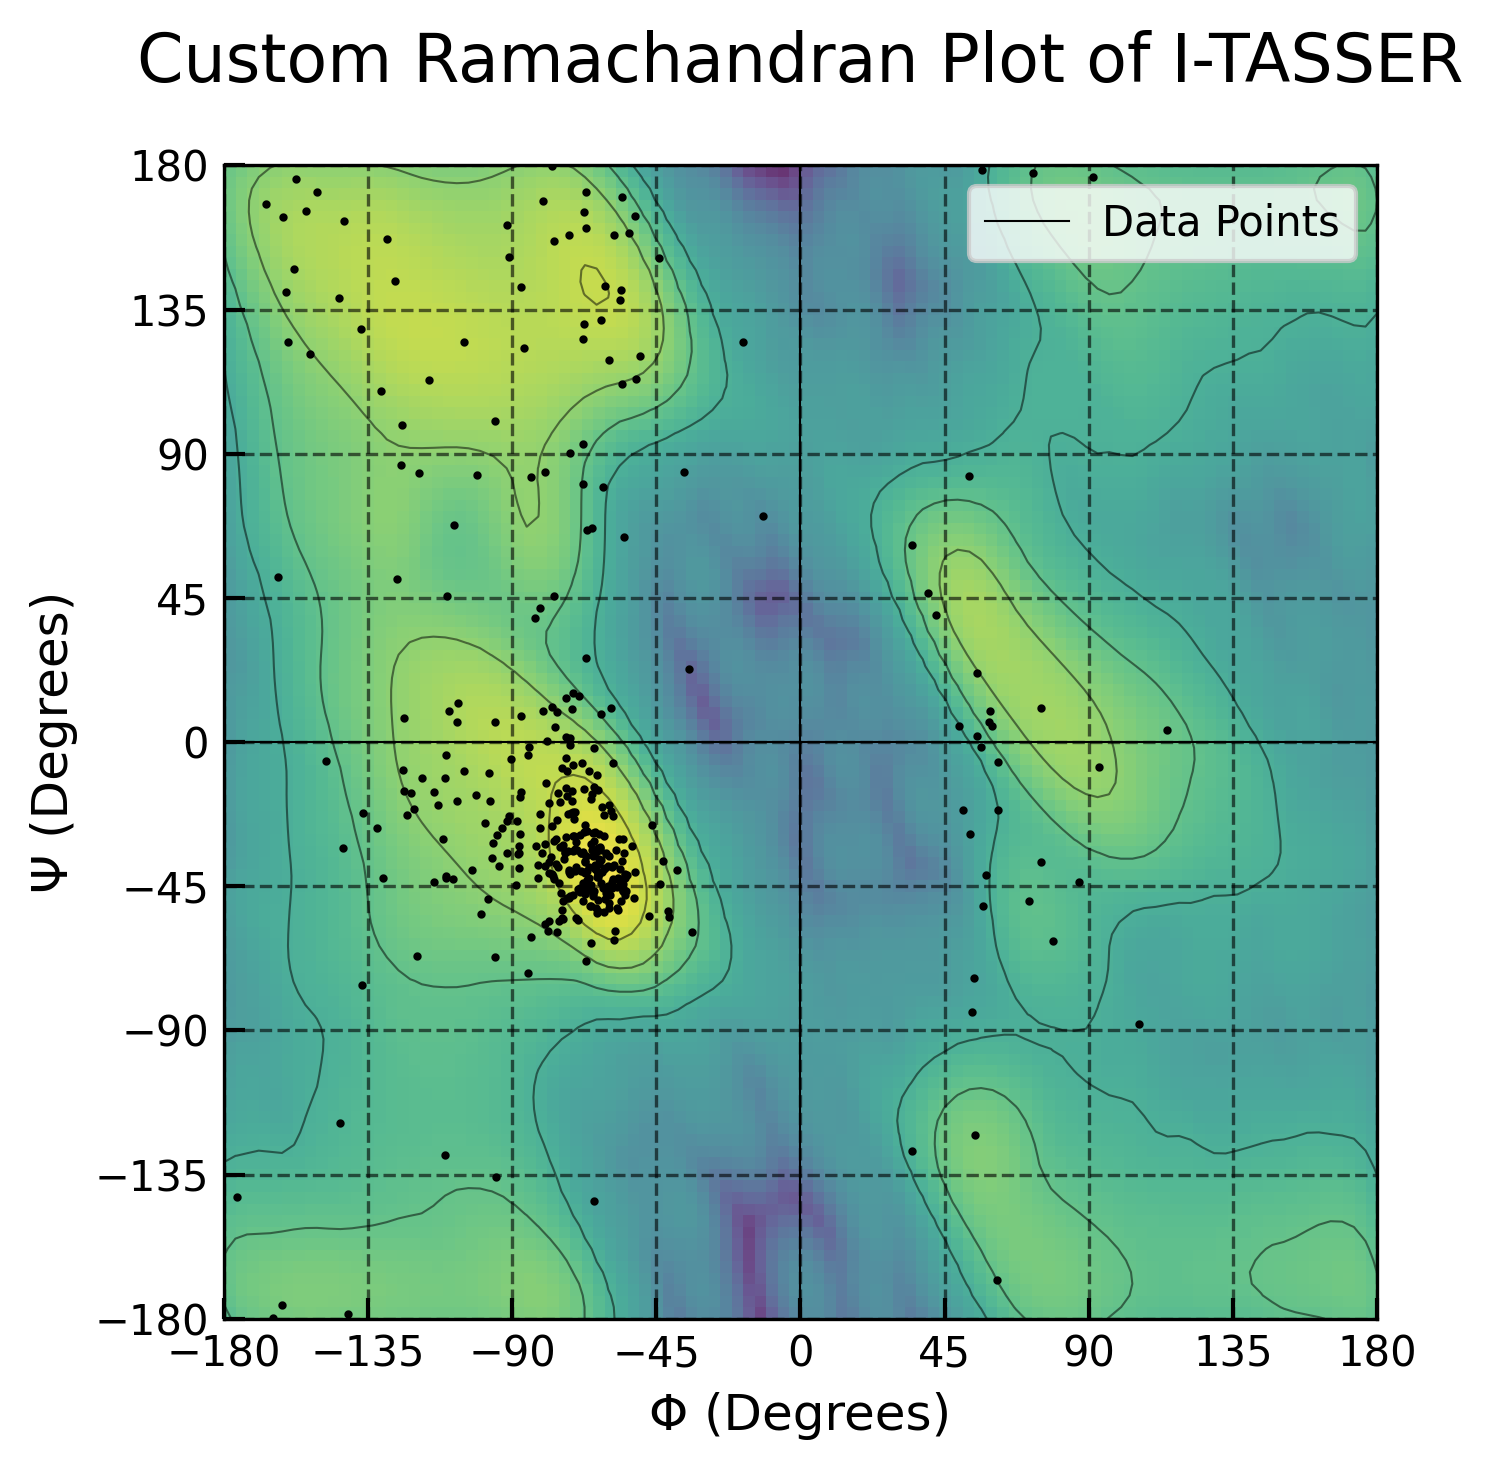

In [12]:
from ramachandraw.utils import plot
import matplotlib.pyplot as plt
from ramachandraw.parser import get_phi_psi
from ramachandraw.utils import fetch_pdb
from scipy.stats import gaussian_kde
import numpy as np
pdb = 'em'
pdb_filepath = f'{pdb}.pdb'
# Draw the Ramachandran plot and get the Axes object
axes = plot(pdb_filepath, cmap="viridis", alpha=0.75, dpi=300, save=False, show=False)

# 定制图形
# 设置标题
axes.set_title('Custom Ramachandran Plot of I-TASSER', fontsize=16, pad=20)

# 设置坐标轴标签
axes.set_xlabel('Φ (Degrees)', fontsize=12)
axes.set_ylabel('Ψ (Degrees)', fontsize=12)

# 设置坐标轴范围
axes.set_xlim(-180, 180)
axes.set_ylim(-180, 180)

# 设置网格线
axes.grid(True, linestyle='--', alpha=0.6)

# 设置背景颜色
axes.set_facecolor('lightgray')

# 设置刻度参数
axes.tick_params(axis='both', labelsize=10, direction='in', length=5, width=1)

# 添加图例
axes.legend(['Data Points'], loc='upper right', fontsize=10)

# 调整边距
plt.tight_layout()

# 保存图形
plt.savefig(f"plot_{pdb}.png", dpi=300)

# 显示图形
#plt.show()

# 获取 phi 和 psi 角度
torsion_angles = get_phi_psi(pdb_filepath)
# 提取 phi 和 psi 值
phi = [angles[0] for angles in torsion_angles.values()]
psi = [angles[1] for angles in torsion_angles.values()]

# 使用核密度估计（KDE）计算密度
data = np.vstack([phi, psi])
kde = gaussian_kde(data)

# 定义密度阈值（根据实际数据调整）
core_threshold = 0.02  # 核心区域密度阈值
allowed_threshold = 0.01  # 允许区域密度阈值
generous_threshold = 0.005  # 宽泛允许区域密度阈值

# 分类残基
core = 0
allowed = 0
generous = 0
disallowed = 0

for residue, angles in torsion_angles.items():
    phi_val = angles[0]
    psi_val = angles[1]
    density_val = kde(np.array([[phi_val, psi_val]]))
    
    if density_val >= core_threshold:
        core += 1
    elif density_val >= allowed_threshold:
        allowed += 1
    elif density_val >= generous_threshold:
        generous += 1
    else:
        disallowed += 1

# 计算总数和百分比
total_residues = len(torsion_angles)
region_percentages = {
    "core": (core / total_residues) * 100,
    "allowed": (allowed / total_residues) * 100,
    "generous": (generous / total_residues) * 100,
    "disallowed": (disallowed / total_residues) * 100
}

# 打印结果
print("最优区域 [A,B,L] 的残基\t{} ({:.1f}%)".format(core, region_percentages["core"]))
print("其他允许区域 [a,b,l,p] 的残基\t{} ({:.1f}%)".format(allowed, region_percentages["allowed"]))
print("宽泛允许区域 [-a,-b,-l,-p] 的残基\t{} ({:.1f}%)".format(generous, region_percentages["generous"]))
print("不允许区域的残基\t{} ({:.1f}%)".format(disallowed, region_percentages["disallowed"]))